# Telecom Customer Churn Analysis Using Data Analytics

**Student Name:** Narmatha Muralidharan  
**Student ID:** 83722937  

---

## Project Overview
This project analyzes telecom customer data to identify key factors driving customer churn and builds predictive models to help telecom companies proactively reduce customer attrition.

**Dataset:** Telco Customer Churn (Kaggle) — 7,043 customers, 21 features


In [ ]:
# upload the dataset

import os

# Check if running in Colab
try:
    from google.colab import files
    print("Running in Google Colab - Please upload the CSV file:")
    uploaded = files.upload()
    for filename in uploaded.keys():
        print(f"Uploaded: {filename}")
    print("Dataset uploaded successfully!")
except ImportError:
    print("Not running in Colab - using local file")
    if os.path.exists('WA_Fn-UseC_-Telco-Customer-Churn.csv'):
        print("Dataset found locally!")
    else:
        print("ERROR: Please place the dataset CSV in this directory")

# Install XGBoost
!pip install -q xgboost
print("Setup complete!")


Running in Google Colab - Please upload the CSV file:


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Uploaded: WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset uploaded successfully!
Setup complete!


## 1. Import Libraries

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import os
os.makedirs('images', exist_ok=True)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)

import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 2. Data Loading & Initial Exploration

In [ ]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
df.head()


Dataset Shape: 7043 rows × 21 columns

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Dataset info
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
df.info()


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

In [ ]:
# Column names and data types
print("\nColumn Names and Types:\n")
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes), 1):
    print(f"  {i:2d}. {col:<25s} → {dtype}")



Column Names and Types:

   1. customerID                → object
   2. gender                    → object
   3. SeniorCitizen             → int64
   4. Partner                   → object
   5. Dependents                → object
   6. tenure                    → int64
   7. PhoneService              → object
   8. MultipleLines             → object
   9. InternetService           → object
  10. OnlineSecurity            → object
  11. OnlineBackup              → object
  12. DeviceProtection          → object
  13. TechSupport               → object
  14. StreamingTV               → object
  15. StreamingMovies           → object
  16. Contract                  → object
  17. PaperlessBilling          → object
  18. PaymentMethod             → object
  19. MonthlyCharges            → float64
  20. TotalCharges              → object
  21. Churn                     → object


In [ ]:
# Statistical summary
print("\nStatistical Summary of Numerical Columns:\n")
df.describe().round(2)



Statistical Summary of Numerical Columns:



,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


## 3. Data Cleaning & Preprocessing

Key cleaning steps:
- Handle missing values in TotalCharges
- Convert data types
- Remove unnecessary columns
- Check for duplicates


In [ ]:
# Check for missing values
print("Missing Values per Column:\n")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No null values found")

# Check TotalCharges - it has blank spaces that need to be converted
print(f"\nTotalCharges dtype: {df['TotalCharges'].dtype}")
print(f"Blank values in TotalCharges: {(df['TotalCharges'] == ' ').sum()}")


Missing Values per Column:

No null values found

TotalCharges dtype: object
Blank values in TotalCharges: 11


In [ ]:
# Fix TotalCharges - convert to numeric, handle blanks
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN values were created
print(f"NaN values in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")

# Fill NaN with median (better than mean for skewed data)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print(f"NaN values after filling: {df['TotalCharges'].isnull().sum()}")
print("✅ TotalCharges cleaned successfully!")


NaN values in TotalCharges after conversion: 11
NaN values after filling: 0
✅ TotalCharges cleaned successfully!


In [ ]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Drop customerID - not useful for analysis
df.drop('customerID', axis=1, inplace=True)
print(f"\n✅ Dropped 'customerID' column")
print(f"Updated shape: {df.shape}")


Duplicate rows: 0

✅ Dropped 'customerID' column
Updated shape: (7043, 20)


In [ ]:
# Convert SeniorCitizen from 0/1 to No/Yes for better visualization
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Verify the final cleaned dataset
print("\nCleaned Dataset Overview:")
print(f"  Rows: {df.shape[0]}")
print(f"  Columns: {df.shape[1]}")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Duplicates: {df.duplicated().sum()}")
print("\n✅ Data cleaning complete!")



Cleaned Dataset Overview:
  Rows: 7043
  Columns: 20
  Missing values: 0
  Duplicates: 22

✅ Data cleaning complete!


## 4. Exploratory Data Analysis (EDA)

Comprehensive visual analysis of customer churn patterns across demographics, services, and billing.


### 4.1 Churn Distribution

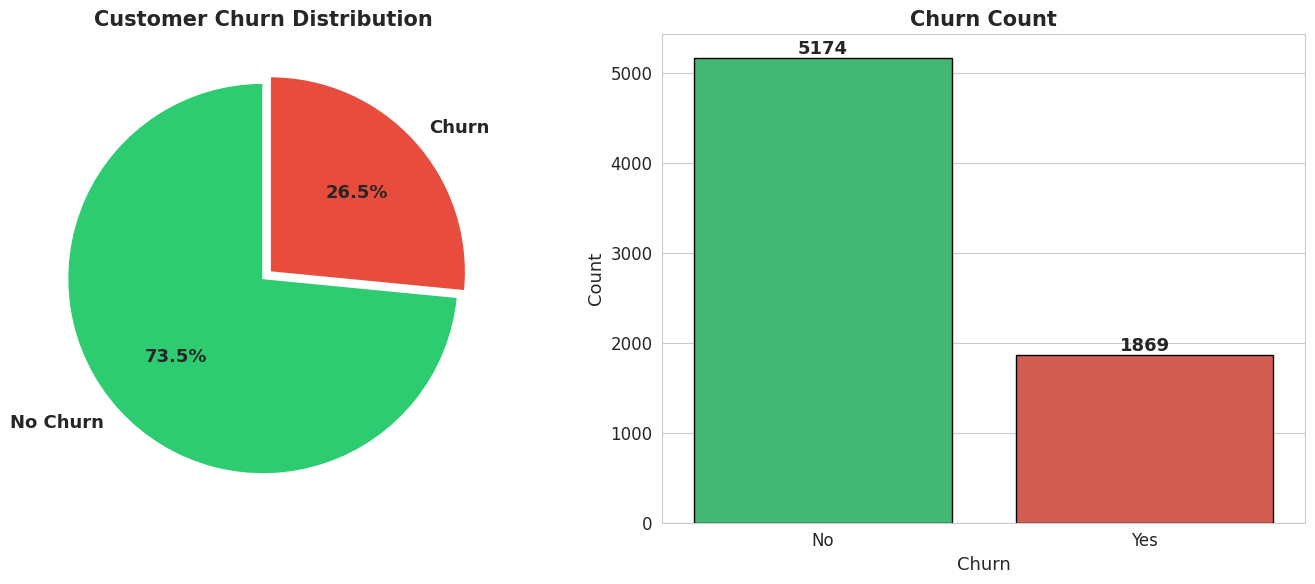


Churn Rate: 26.5%
Retained: 5174 | Churned: 1869


In [ ]:
# Churn Distribution - Pie Chart & Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie Chart
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[0].set_title('Customer Churn Distribution', fontsize=15, fontweight='bold')

# Bar Chart
sns.countplot(data=df, x='Churn', palette=colors, ax=axes[1], edgecolor='black')
axes[1].set_title('Churn Count', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Churn', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('images/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChurn Rate: {(df['Churn'] == 'Yes').mean()*100:.1f}%")
print(f"Retained: {churn_counts['No']} | Churned: {churn_counts['Yes']}")


### 4.2 Churn by Gender

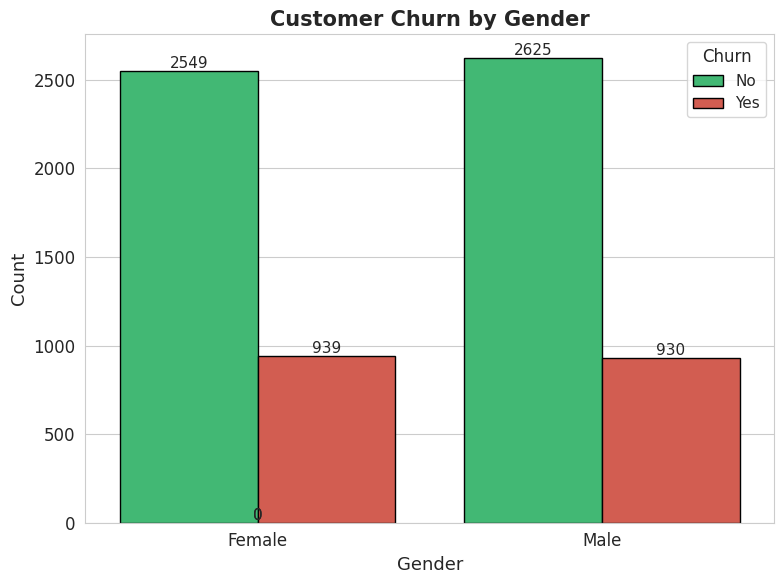


Churn Rate by Gender:
  Female: 26.9%
  Male: 26.2%


In [ ]:
# Churn by Gender
fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(data=df, x='gender', hue='Churn', palette=['#2ecc71', '#e74c3c'],
              edgecolor='black', ax=ax)
ax.set_title('Customer Churn by Gender', fontsize=15, fontweight='bold')
ax.set_xlabel('Gender', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.legend(title='Churn', fontsize=11)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('images/02_churn_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

# Gender churn rates
gender_churn = df.groupby('gender')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
print(f"\nChurn Rate by Gender:")
for gender, rate in gender_churn.items():
    print(f"  {gender}: {rate}%")


### 4.3 Churn by Contract Type

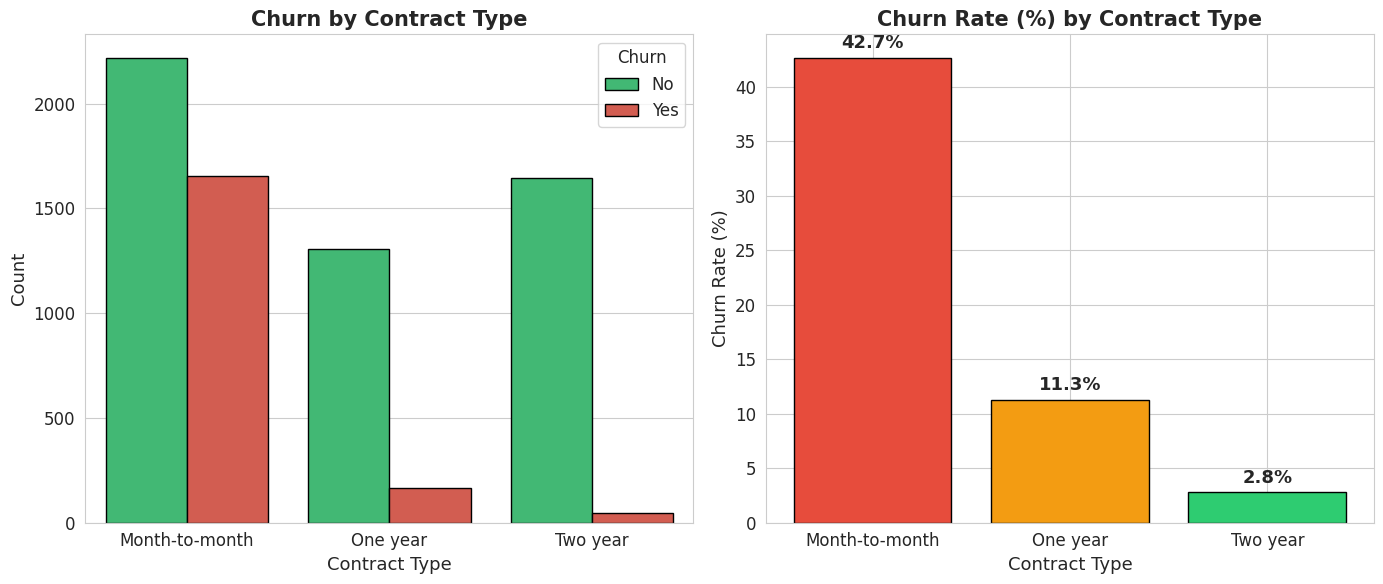


⚠️ Key Insight: Month-to-month customers have the HIGHEST churn rate!


In [ ]:
# Churn by Contract Type
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'],
              edgecolor='black', ax=axes[0], order=['Month-to-month', 'One year', 'Two year'])
axes[0].set_title('Churn by Contract Type', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Contract Type', fontsize=13)
axes[0].set_ylabel('Count', fontsize=13)
axes[0].legend(title='Churn')

# Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
contract_churn = contract_churn.reindex(['Month-to-month', 'One year', 'Two year'])
bars = axes[1].bar(contract_churn.index, contract_churn.values,
                   color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
axes[1].set_title('Churn Rate (%) by Contract Type', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Contract Type', fontsize=13)
axes[1].set_ylabel('Churn Rate (%)', fontsize=13)
for bar, val in zip(bars, contract_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('images/03_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n⚠️ Key Insight: Month-to-month customers have the HIGHEST churn rate!")


### 4.4 Churn by Internet Service Type

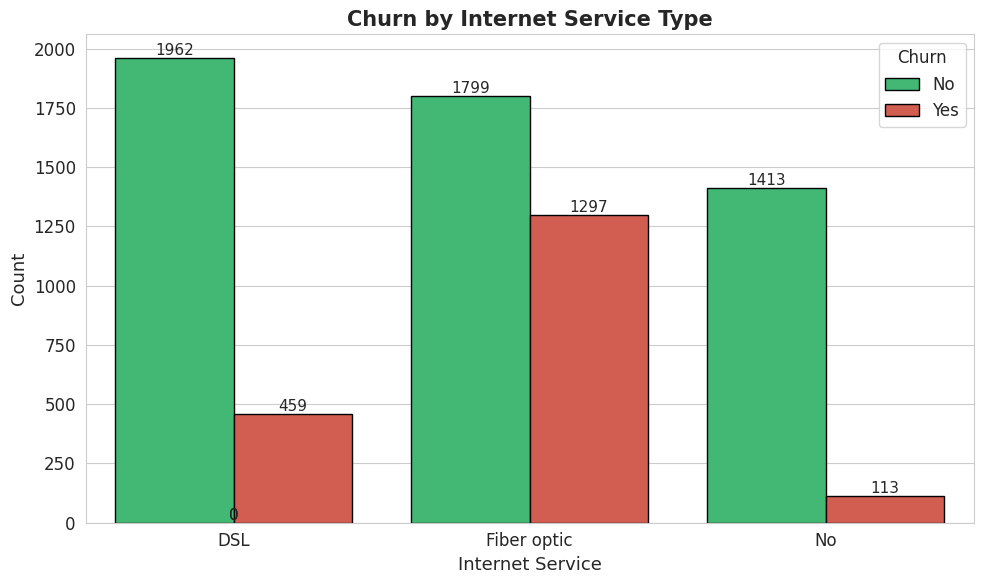


Churn Rate by Internet Service:
  DSL: 19.0%
  Fiber optic: 41.9%
  No: 7.4%


In [ ]:
# Churn by Internet Service
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df, x='InternetService', hue='Churn', palette=['#2ecc71', '#e74c3c'],
              edgecolor='black', ax=ax)
ax.set_title('Churn by Internet Service Type', fontsize=15, fontweight='bold')
ax.set_xlabel('Internet Service', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.legend(title='Churn')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('images/04_churn_by_internet.png', dpi=150, bbox_inches='tight')
plt.show()

internet_churn = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
print("\nChurn Rate by Internet Service:")
for svc, rate in internet_churn.items():
    print(f"  {svc}: {rate}%")


### 4.5 Churn by Payment Method

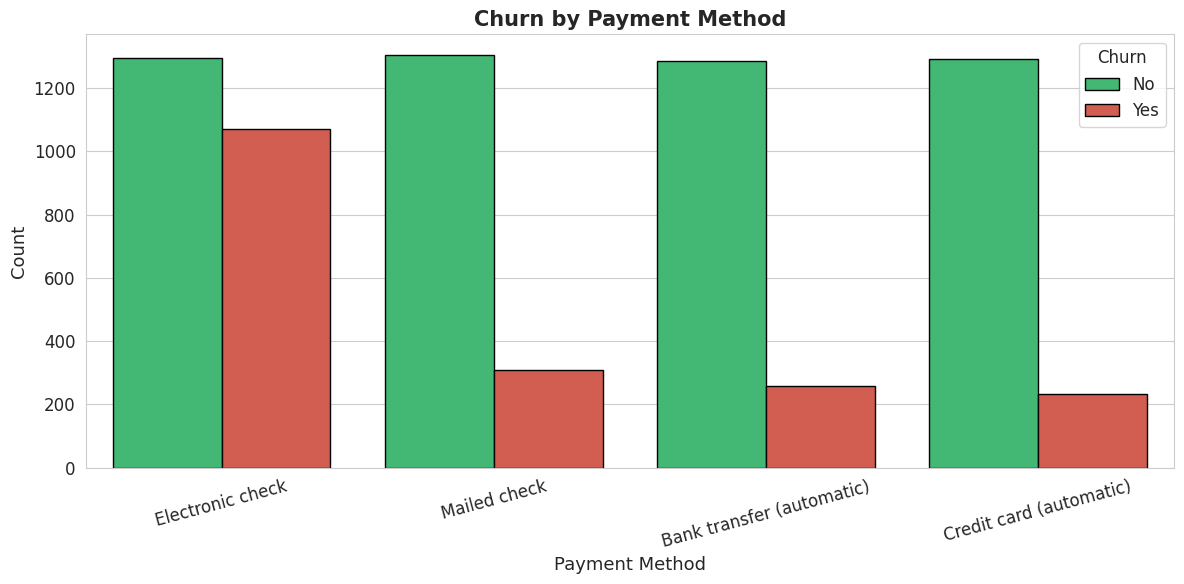


Churn Rate by Payment Method:
  Electronic check: 45.3%
  Mailed check: 19.1%
  Bank transfer (automatic): 16.7%
  Credit card (automatic): 15.2%


In [ ]:
# Churn by Payment Method
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette=['#2ecc71', '#e74c3c'],
              edgecolor='black', ax=ax)
ax.set_title('Churn by Payment Method', fontsize=15, fontweight='bold')
ax.set_xlabel('Payment Method', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.legend(title='Churn')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('images/05_churn_by_payment.png', dpi=150, bbox_inches='tight')
plt.show()

payment_churn = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
print("\nChurn Rate by Payment Method:")
for method, rate in payment_churn.sort_values(ascending=False).items():
    print(f"  {method}: {rate}%")


### 4.6 Tenure Distribution by Churn Status

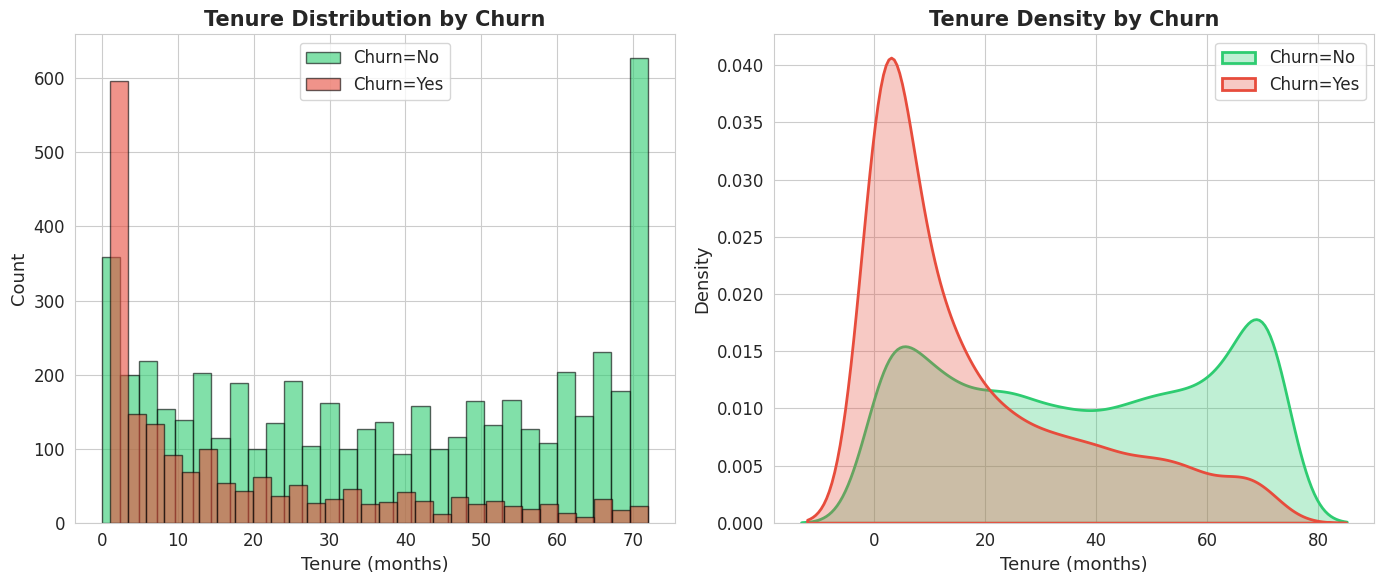


Avg Tenure - Churned: 18.0 months
Avg Tenure - Retained: 37.6 months

⚠️ Key Insight: New customers (low tenure) are MORE likely to churn!


In [ ]:
# Tenure Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
    subset = df[df['Churn'] == label]
    axes[0].hist(subset['tenure'], bins=30, alpha=0.6, label=f'Churn={label}',
                 color=color, edgecolor='black')
axes[0].set_title('Tenure Distribution by Churn', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Tenure (months)', fontsize=13)
axes[0].set_ylabel('Count', fontsize=13)
axes[0].legend(fontsize=12)

# KDE Plot
for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
    subset = df[df['Churn'] == label]
    sns.kdeplot(subset['tenure'], ax=axes[1], label=f'Churn={label}',
                color=color, linewidth=2, fill=True, alpha=0.3)
axes[1].set_title('Tenure Density by Churn', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Tenure (months)', fontsize=13)
axes[1].set_ylabel('Density', fontsize=13)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.savefig('images/06_tenure_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAvg Tenure - Churned: {df[df['Churn']=='Yes']['tenure'].mean():.1f} months")
print(f"Avg Tenure - Retained: {df[df['Churn']=='No']['tenure'].mean():.1f} months")
print("\n⚠️ Key Insight: New customers (low tenure) are MORE likely to churn!")


### 4.7 Monthly Charges by Churn Status

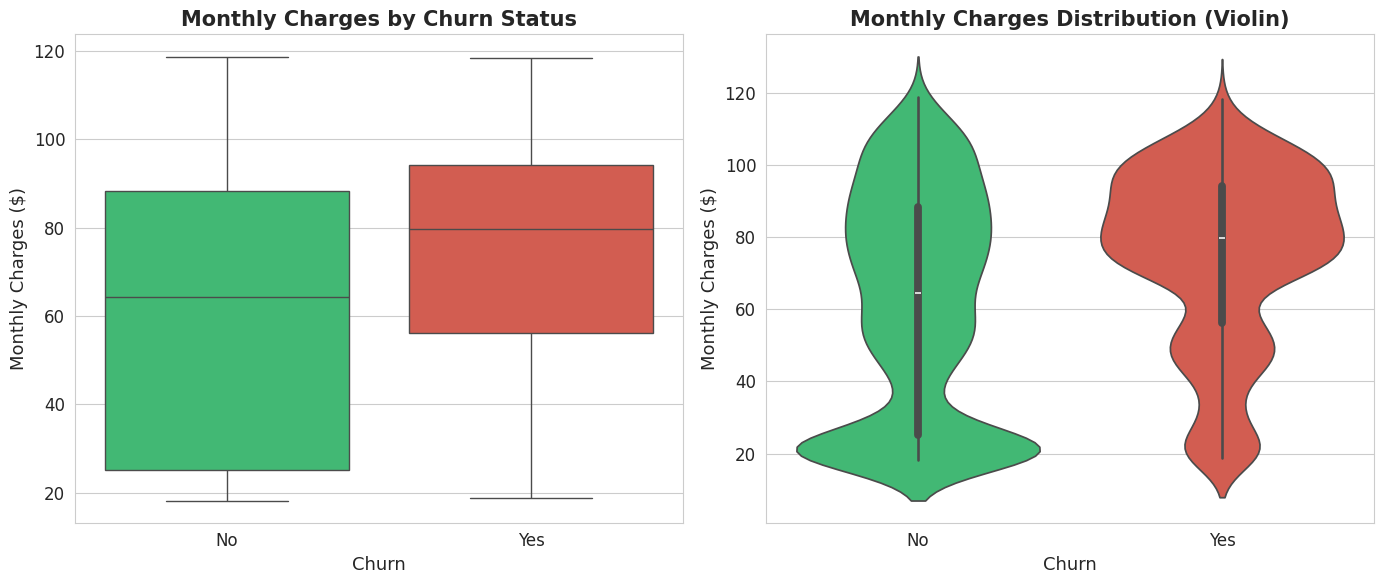


Avg Monthly Charges - Churned: $74.44
Avg Monthly Charges - Retained: $61.27

⚠️ Key Insight: Churned customers pay HIGHER monthly charges!


In [ ]:
# Monthly Charges Box Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box Plot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'],
            ax=axes[0])
axes[0].set_title('Monthly Charges by Churn Status', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Churn', fontsize=13)
axes[0].set_ylabel('Monthly Charges ($)', fontsize=13)

# Violin Plot
sns.violinplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'],
               ax=axes[1])
axes[1].set_title('Monthly Charges Distribution (Violin)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Churn', fontsize=13)
axes[1].set_ylabel('Monthly Charges ($)', fontsize=13)

plt.tight_layout()
plt.savefig('images/07_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAvg Monthly Charges - Churned: ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"Avg Monthly Charges - Retained: ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")
print("\n⚠️ Key Insight: Churned customers pay HIGHER monthly charges!")


### 4.8 Correlation Heatmap

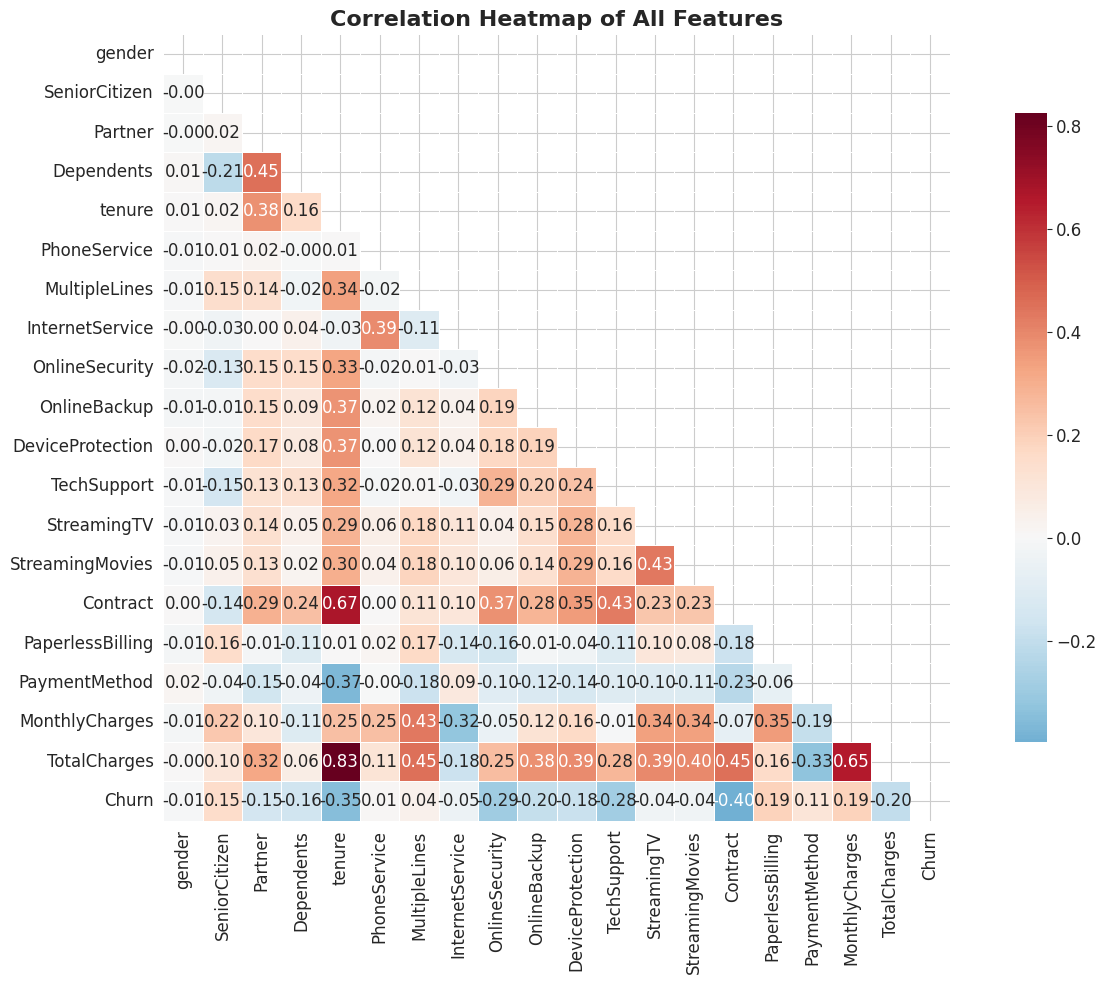


Top Features Correlated with Churn:
  Positive (increase churn):
    MonthlyCharges: 0.193
    PaperlessBilling: 0.192
    SeniorCitizen: 0.151
    PaymentMethod: 0.107
    MultipleLines: 0.038
  Negative (decrease churn):
    TotalCharges: -0.199
    TechSupport: -0.282
    OnlineSecurity: -0.289
    tenure: -0.352
    Contract: -0.397


In [ ]:
# Correlation Heatmap for numerical features
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap of All Features', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('images/08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with Churn
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(ascending=False)
print("\nTop Features Correlated with Churn:")
print("  Positive (increase churn):")
for feat, val in churn_corr.head(5).items():
    print(f"    {feat}: {val:.3f}")
print("  Negative (decrease churn):")
for feat, val in churn_corr.tail(5).items():
    print(f"    {feat}: {val:.3f}")


### 4.9 Churn by Senior Citizen Status

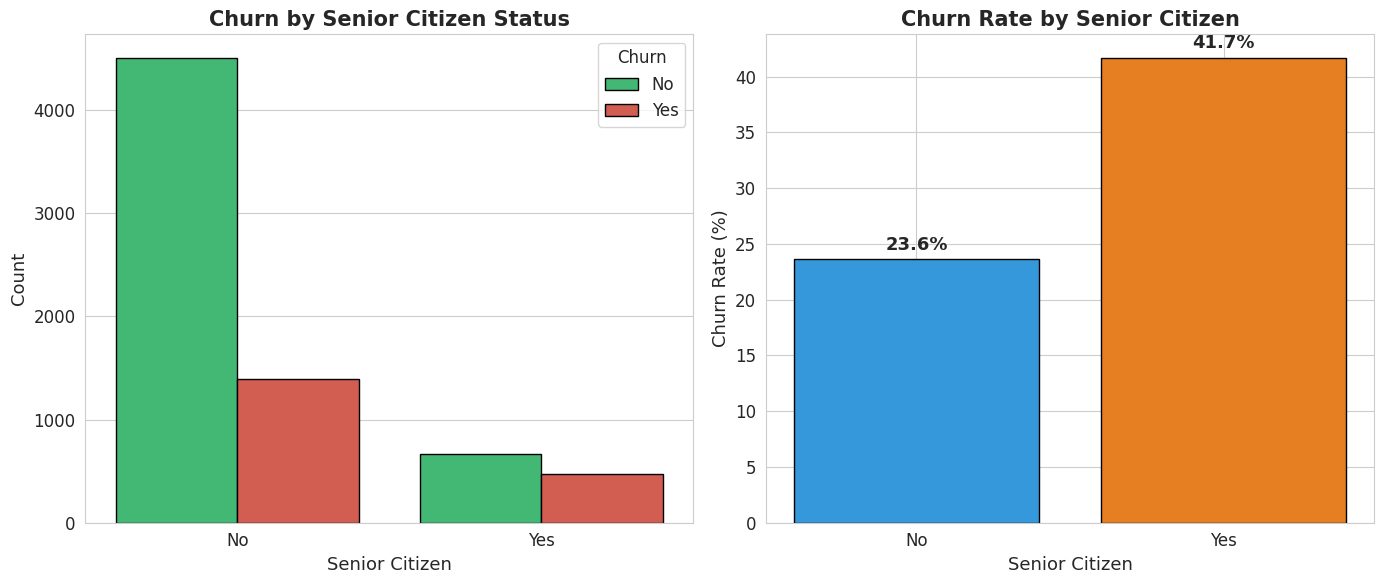


⚠️ Key Insight: Senior citizens have a HIGHER churn rate!


In [ ]:
# Churn by Senior Citizen
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette=['#2ecc71', '#e74c3c'],
              edgecolor='black', ax=axes[0])
axes[0].set_title('Churn by Senior Citizen Status', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Senior Citizen', fontsize=13)
axes[0].set_ylabel('Count', fontsize=13)
axes[0].legend(title='Churn')

# Churn rate comparison
senior_churn = df.groupby('SeniorCitizen')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
bars = axes[1].bar(senior_churn.index, senior_churn.values,
                   color=['#3498db', '#e67e22'], edgecolor='black')
axes[1].set_title('Churn Rate by Senior Citizen', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Senior Citizen', fontsize=13)
axes[1].set_ylabel('Churn Rate (%)', fontsize=13)
for bar, val in zip(bars, senior_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('images/09_churn_by_senior.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n⚠️ Key Insight: Senior citizens have a HIGHER churn rate!")


### 4.10 Churn by Tech Support & Online Security

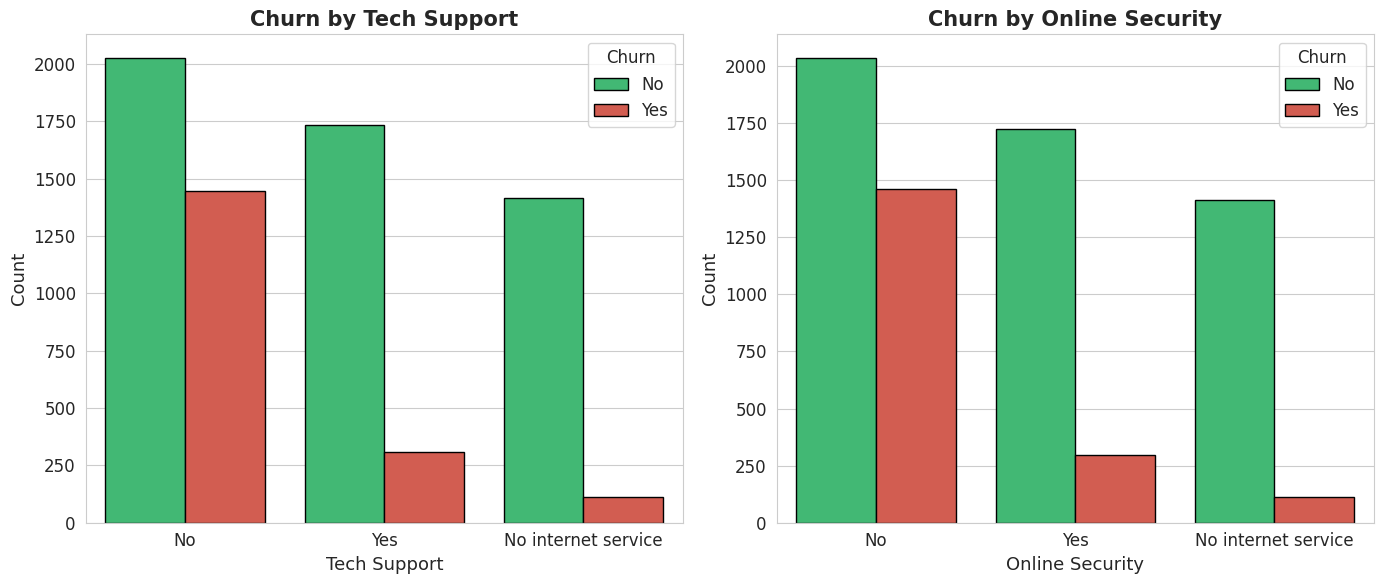


Churn Rate by TechSupport:
  No: 41.6%
  No internet service: 7.4%
  Yes: 15.2%

Churn Rate by OnlineSecurity:
  No: 41.8%
  No internet service: 7.4%
  Yes: 14.6%


In [ ]:
# Churn by Tech Support and Online Security
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=df, x='TechSupport', hue='Churn', palette=['#2ecc71', '#e74c3c'],
              edgecolor='black', ax=axes[0])
axes[0].set_title('Churn by Tech Support', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Tech Support', fontsize=13)
axes[0].set_ylabel('Count', fontsize=13)
axes[0].legend(title='Churn')

sns.countplot(data=df, x='OnlineSecurity', hue='Churn', palette=['#2ecc71', '#e74c3c'],
              edgecolor='black', ax=axes[1])
axes[1].set_title('Churn by Online Security', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Online Security', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].legend(title='Churn')

plt.tight_layout()
plt.savefig('images/10_churn_support_security.png', dpi=150, bbox_inches='tight')
plt.show()

for feat in ['TechSupport', 'OnlineSecurity']:
    rates = df.groupby(feat)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
    print(f"\nChurn Rate by {feat}:")
    for val, rate in rates.items():
        print(f"  {val}: {rate}%")


### 4.11 Churn by Partner & Dependents

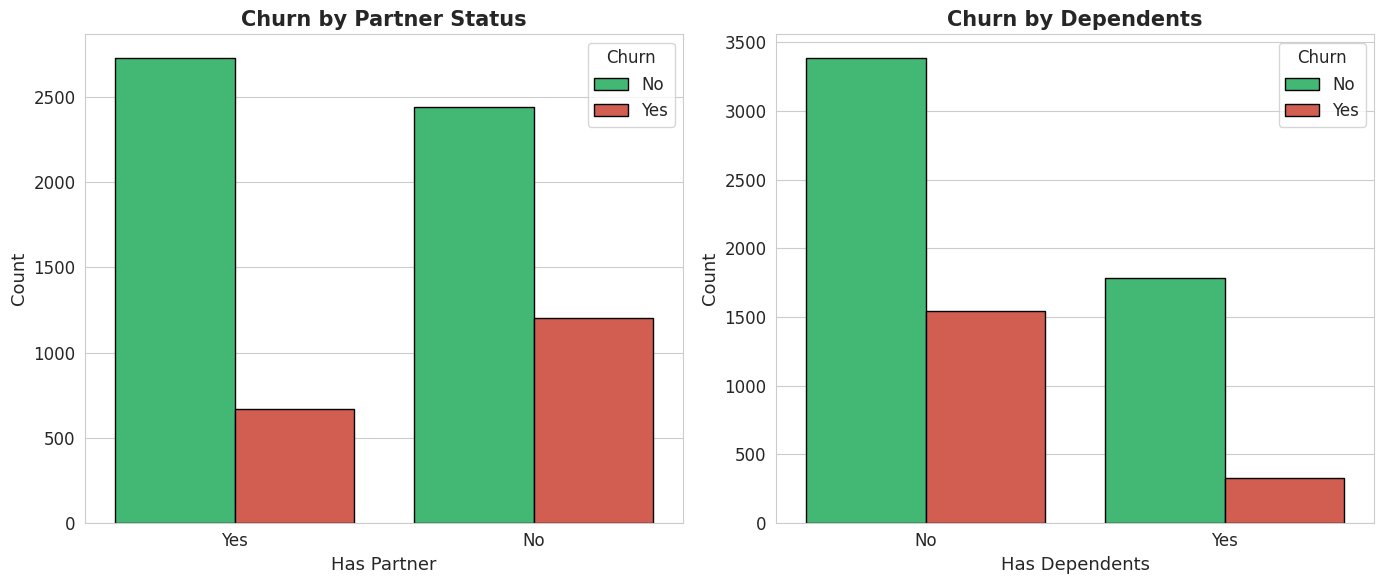


⚠️ Key Insight: Customers WITHOUT partner/dependents churn more!


In [ ]:
# Churn by Partner and Dependents
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=df, x='Partner', hue='Churn', palette=['#2ecc71', '#e74c3c'],
              edgecolor='black', ax=axes[0])
axes[0].set_title('Churn by Partner Status', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Has Partner', fontsize=13)
axes[0].set_ylabel('Count', fontsize=13)
axes[0].legend(title='Churn')

sns.countplot(data=df, x='Dependents', hue='Churn', palette=['#2ecc71', '#e74c3c'],
              edgecolor='black', ax=axes[1])
axes[1].set_title('Churn by Dependents', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Has Dependents', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].legend(title='Churn')

plt.tight_layout()
plt.savefig('images/11_churn_partner_dependents.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n⚠️ Key Insight: Customers WITHOUT partner/dependents churn more!")


### 4.12 Total Charges Distribution by Churn

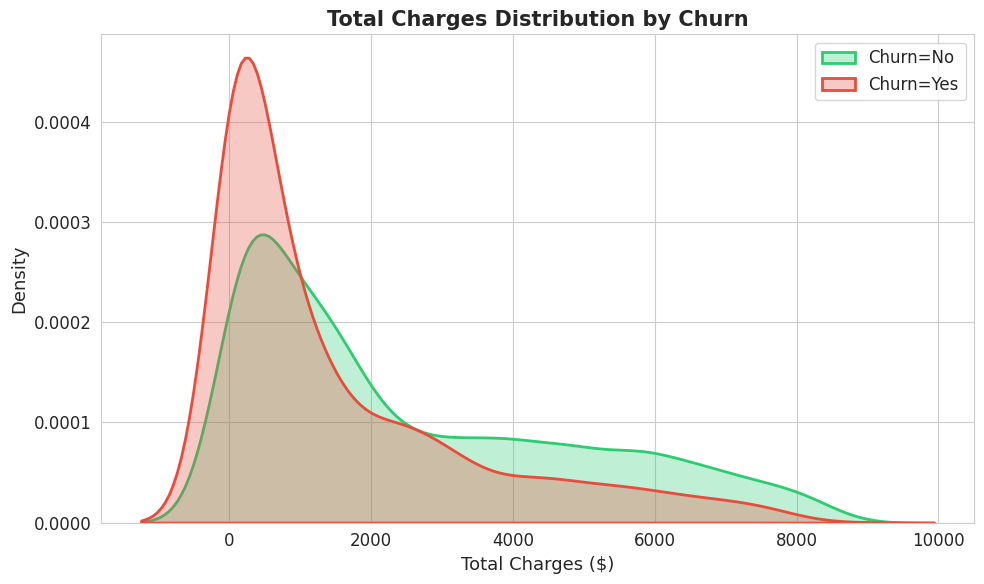


Avg Total Charges - Churned: $1531.80
Avg Total Charges - Retained: $2552.88


In [ ]:
# Total Charges Distribution
fig, ax = plt.subplots(figsize=(10, 6))
for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
    subset = df[df['Churn'] == label]
    sns.kdeplot(subset['TotalCharges'], ax=ax, label=f'Churn={label}',
                color=color, linewidth=2, fill=True, alpha=0.3)
ax.set_title('Total Charges Distribution by Churn', fontsize=15, fontweight='bold')
ax.set_xlabel('Total Charges ($)', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('images/12_total_charges.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAvg Total Charges - Churned: ${df[df['Churn']=='Yes']['TotalCharges'].mean():.2f}")
print(f"Avg Total Charges - Retained: ${df[df['Churn']=='No']['TotalCharges'].mean():.2f}")


## 5. Statistical Analysis

Performing hypothesis tests to validate our EDA findings with statistical significance.


### 5.1 Chi-Square Test: Churn vs Contract Type

In [ ]:
# Chi-Square Test: Is churn independent of contract type?
print("=" * 60)
print("CHI-SQUARE TEST: Churn vs Contract Type")
print("=" * 60)
print("\nH0: Churn is independent of Contract Type")
print("H1: Churn is dependent on Contract Type")

contingency_table = pd.crosstab(df['Contract'], df['Churn'])
print("\nContingency Table:")
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of Freedom: {dof}")

alpha = 0.05
if p_value < alpha:
    print(f"\n✅ RESULT: p-value ({p_value:.6f}) < α ({alpha})")
    print("   → REJECT H0: Churn IS significantly dependent on Contract Type!")
else:
    print(f"\n❌ RESULT: p-value ({p_value:.6f}) >= α ({alpha})")
    print("   → FAIL TO REJECT H0: No significant relationship found.")


CHI-SQUARE TEST: Churn vs Contract Type

H0: Churn is independent of Contract Type
H1: Churn is dependent on Contract Type

Contingency Table:
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Chi-Square Statistic: 1184.5966
P-value: 0.000000
Degrees of Freedom: 2

✅ RESULT: p-value (0.000000) < α (0.05)
   → REJECT H0: Churn IS significantly dependent on Contract Type!


### 5.2 T-Test: Monthly Charges (Churned vs Retained)

In [ ]:
# Independent T-Test: Monthly Charges between churned and retained
print("=" * 60)
print("INDEPENDENT T-TEST: Monthly Charges")
print("=" * 60)
print("\nH0: Mean monthly charges are EQUAL for churned and retained customers")
print("H1: Mean monthly charges are DIFFERENT for churned and retained customers")

churned_charges = df[df['Churn'] == 'Yes']['MonthlyCharges']
retained_charges = df[df['Churn'] == 'No']['MonthlyCharges']

t_stat, p_value = ttest_ind(churned_charges, retained_charges)
print(f"\nMean Monthly Charges (Churned):  ${churned_charges.mean():.2f}")
print(f"Mean Monthly Charges (Retained): ${retained_charges.mean():.2f}")
print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n✅ RESULT: p-value ({p_value:.6f}) < α ({alpha})")
    print("   → REJECT H0: Monthly charges ARE significantly different!")
    print("   → Churned customers pay significantly MORE!")
else:
    print(f"\n❌ RESULT: p-value ({p_value:.6f}) >= α ({alpha})")
    print("   → FAIL TO REJECT H0: No significant difference found.")


INDEPENDENT T-TEST: Monthly Charges

H0: Mean monthly charges are EQUAL for churned and retained customers
H1: Mean monthly charges are DIFFERENT for churned and retained customers

Mean Monthly Charges (Churned):  $74.44
Mean Monthly Charges (Retained): $61.27

T-Statistic: 16.5367
P-value: 0.000000

✅ RESULT: p-value (0.000000) < α (0.05)
   → REJECT H0: Monthly charges ARE significantly different!
   → Churned customers pay significantly MORE!


### 5.3 Chi-Square Test: Churn vs Internet Service

In [ ]:
# Chi-Square Test: Churn vs Internet Service
print("=" * 60)
print("CHI-SQUARE TEST: Churn vs Internet Service")
print("=" * 60)
print("\nH0: Churn is independent of Internet Service type")
print("H1: Churn is dependent on Internet Service type")

contingency_table2 = pd.crosstab(df['InternetService'], df['Churn'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table2)
print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n✅ RESULT: p-value ({p_value:.6f}) < α ({alpha})")
    print("   → REJECT H0: Churn IS significantly dependent on Internet Service!")
else:
    print(f"\n❌ RESULT: Fail to reject H0.")


CHI-SQUARE TEST: Churn vs Internet Service

H0: Churn is independent of Internet Service type
H1: Churn is dependent on Internet Service type

Chi-Square Statistic: 732.3096
P-value: 0.000000

✅ RESULT: p-value (0.000000) < α (0.05)
   → REJECT H0: Churn IS significantly dependent on Internet Service!


## 6. Feature Engineering & Data Preparation

Preparing data for machine learning models.


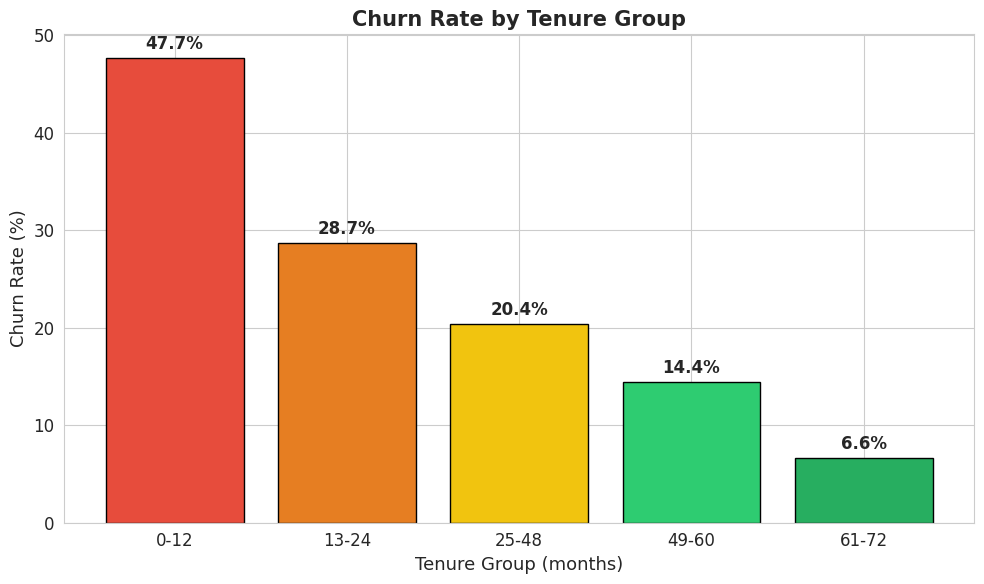

In [ ]:
# Create tenure groups for better analysis
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 60, 72],
                           labels=['0-12', '13-24', '25-48', '49-60', '61-72'])

# Visualize tenure groups vs churn
fig, ax = plt.subplots(figsize=(10, 6))
tenure_churn = df.groupby('TenureGroup')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
bars = ax.bar(tenure_churn.index.astype(str), tenure_churn.values,
              color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60'],
              edgecolor='black')
ax.set_title('Churn Rate by Tenure Group', fontsize=15, fontweight='bold')
ax.set_xlabel('Tenure Group (months)', fontsize=13)
ax.set_ylabel('Churn Rate (%)', fontsize=13)
for bar, val in zip(bars, tenure_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('images/13_churn_by_tenure_group.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Prepare data for ML models
df_ml = df.drop('TenureGroup', axis=1)  # Drop the group column

# Label Encoding for all categorical columns
le = LabelEncoder()
df_ml_encoded = df_ml.copy()
categorical_cols = df_ml_encoded.select_dtypes(include='object').columns
print("Encoding categorical columns:")
for col in categorical_cols:
    df_ml_encoded[col] = le.fit_transform(df_ml_encoded[col])
    print(f"  ✅ {col}")

# Separate features and target
X = df_ml_encoded.drop('Churn', axis=1)
y = df_ml_encoded['Churn']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")


Encoding categorical columns:
  ✅ gender
  ✅ SeniorCitizen
  ✅ Partner
  ✅ Dependents
  ✅ PhoneService
  ✅ MultipleLines
  ✅ InternetService
  ✅ OnlineSecurity
  ✅ OnlineBackup
  ✅ DeviceProtection
  ✅ TechSupport
  ✅ StreamingTV
  ✅ StreamingMovies
  ✅ Contract
  ✅ PaperlessBilling
  ✅ PaymentMethod
  ✅ Churn

Features shape: (7043, 19)
Target shape: (7043,)
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# Scale numerical features
scaler = StandardScaler()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTesting target distribution:\n{y_test.value_counts()}")
print("\n✅ Data prepared for modeling!")


Training set: 5634 samples
Testing set:  1409 samples

Training target distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1035
1     374
Name: count, dtype: int64

✅ Data prepared for modeling!


## 7. Model Building & Evaluation

Building and comparing 4 classification models:
1. Logistic Regression (Baseline)
2. Decision Tree
3. Random Forest
4. XGBoost (Advanced)


In [ ]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                              use_label_encoder=False)
}

# Train and evaluate each model
results = {}
print("=" * 70)
print("MODEL TRAINING & EVALUATION")
print("=" * 70)

for name, model in models.items():
    print(f"\n{'─' * 50}")
    print(f"📊 {name}")
    print(f"{'─' * 50}")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc,
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")

print("\n✅ All models trained successfully!")


MODEL TRAINING & EVALUATION

──────────────────────────────────────────────────
📊 Logistic Regression
──────────────────────────────────────────────────
  Accuracy:  0.8006
  Precision: 0.6467
  Recall:    0.5481
  F1-Score:  0.5933
  AUC-ROC:   0.8403

──────────────────────────────────────────────────
📊 Decision Tree
──────────────────────────────────────────────────
  Accuracy:  0.7850
  Precision: 0.6035
  Recall:    0.5535
  F1-Score:  0.5774
  AUC-ROC:   0.8217

──────────────────────────────────────────────────
📊 Random Forest
──────────────────────────────────────────────────
  Accuracy:  0.7935
  Precision: 0.6388
  Recall:    0.5107
  F1-Score:  0.5676
  AUC-ROC:   0.8219

──────────────────────────────────────────────────
📊 XGBoost
──────────────────────────────────────────────────
  Accuracy:  0.7807
  Precision: 0.6012
  Recall:    0.5160
  F1-Score:  0.5554
  AUC-ROC:   0.8156

✅ All models trained successfully!


### 7.1 Model Comparison


MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.8006     0.6467  0.5481    0.5933   0.8403
Decision Tree          0.7850     0.6035  0.5535    0.5774   0.8217
Random Forest          0.7935     0.6388  0.5107    0.5676   0.8219
XGBoost                0.7807     0.6012  0.5160    0.5554   0.8156


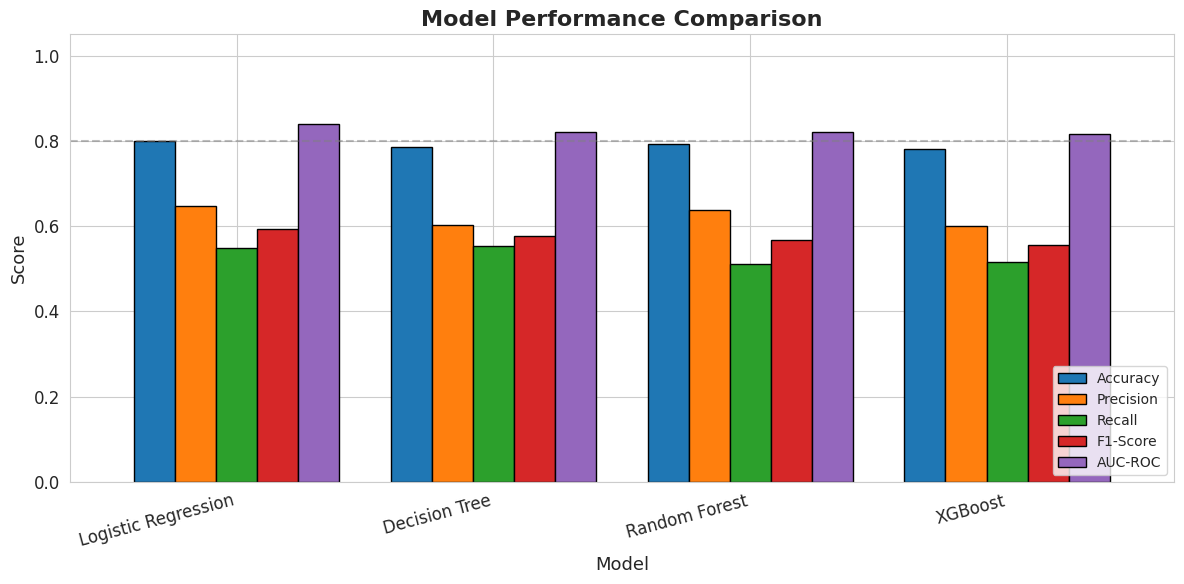


🏆 Best Model (by F1-Score): Logistic Regression


In [ ]:
# Model Comparison Table
comparison_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['model', 'y_pred', 'y_prob']}
    for name, metrics in results.items()
}).T.round(4)

print("\n" + "=" * 70)
print("MODEL COMPARISON TABLE")
print("=" * 70)
print(comparison_df.to_string())

# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', fontsize=10)
plt.xticks(rotation=15, ha='right')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 threshold')

plt.tight_layout()
plt.savefig('images/14_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Best model
best_model_name = comparison_df['F1-Score'].idxmax()
print(f"\n🏆 Best Model (by F1-Score): {best_model_name}")


### 7.2 Confusion Matrix — Best Model

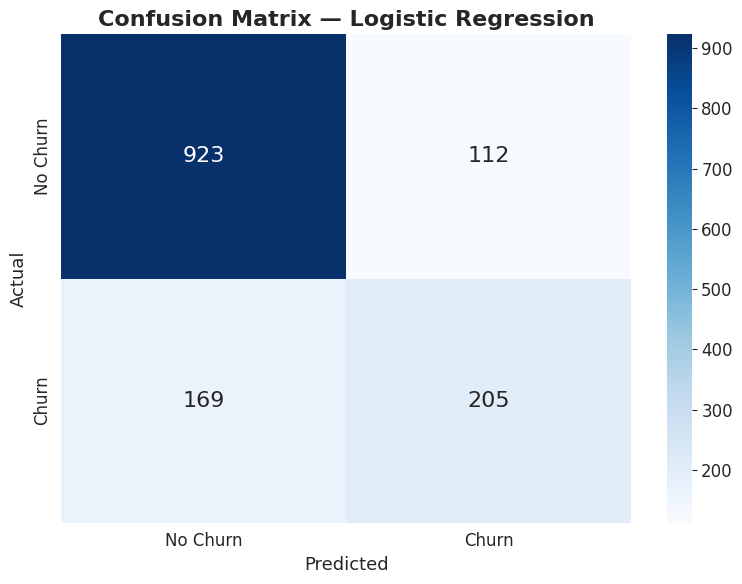


Classification Report — Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [ ]:
# Confusion Matrix for best model
best_name = comparison_df['F1-Score'].idxmax()
best_pred = results[best_name]['y_pred']

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'],
            annot_kws={'size': 16})
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=16, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)

plt.tight_layout()
plt.savefig('images/15_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClassification Report — {best_name}:")
print(classification_report(y_test, best_pred, target_names=['No Churn', 'Churn']))


### 7.3 ROC Curve Comparison

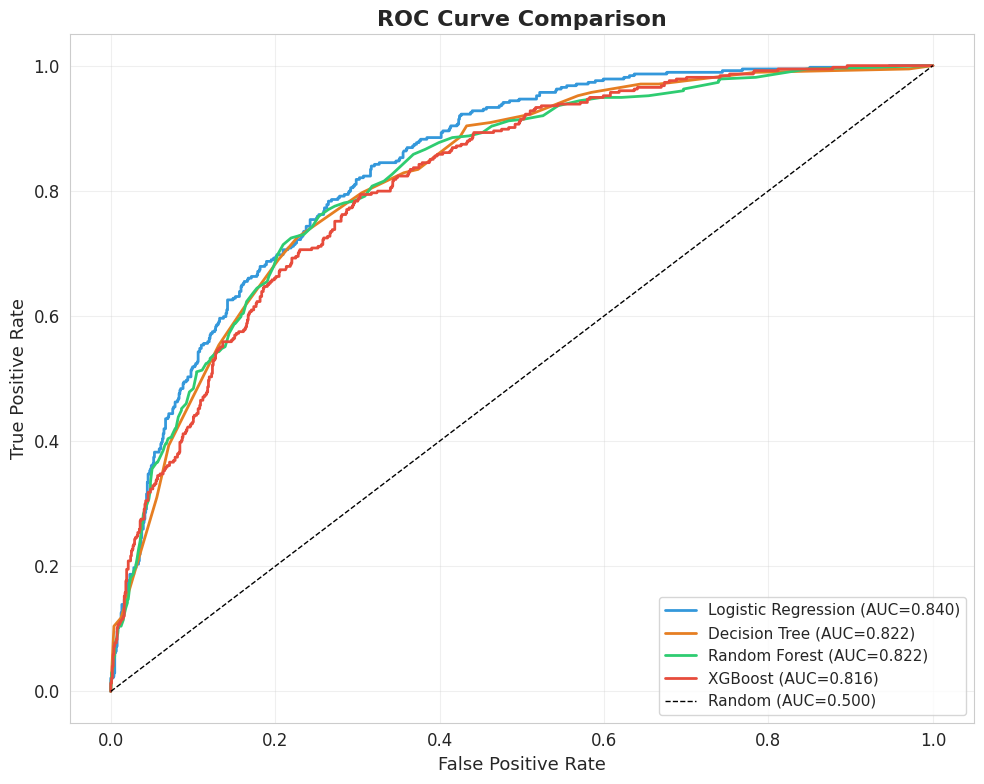

In [ ]:
# ROC Curve for all models
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']

for (name, metrics), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, metrics['y_prob'])
    auc_val = metrics['AUC-ROC']
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
ax.set_title('ROC Curve Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/16_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.4 Feature Importance — Top Churn Drivers

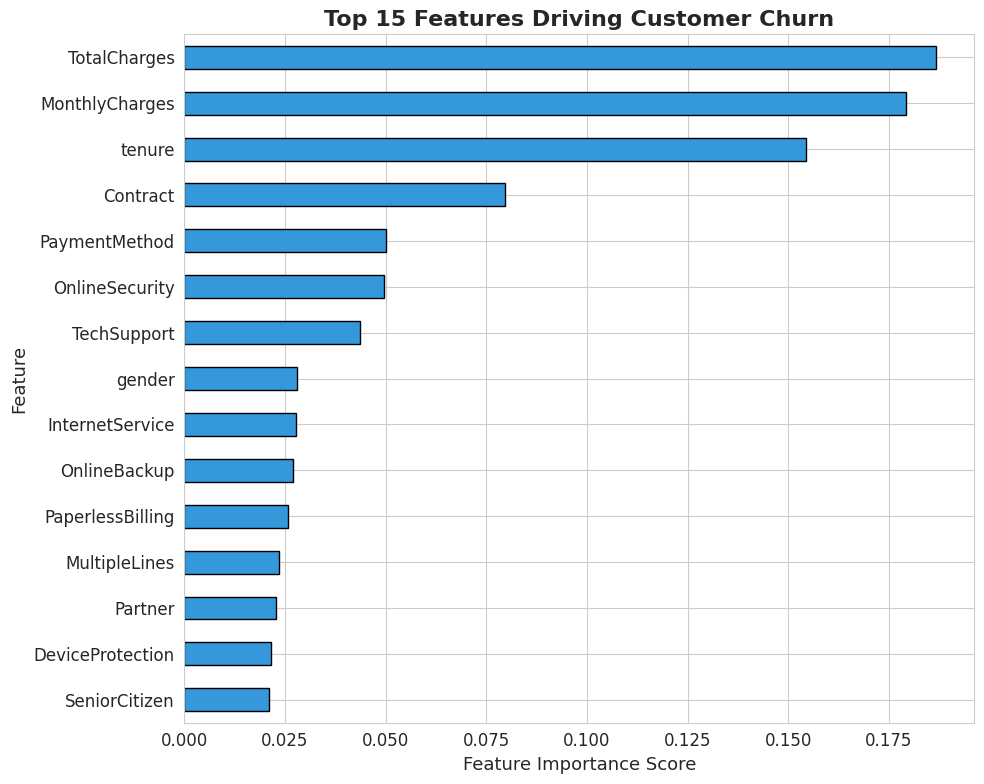


Top 5 Churn Drivers:
  1. TotalCharges: 0.1868
  2. MonthlyCharges: 0.1792
  3. tenure: 0.1543
  4. Contract: 0.0796
  5. PaymentMethod: 0.0501


In [ ]:
# Feature Importance from Random Forest
rf_model = results['Random Forest']['model']
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
feature_importance.tail(15).plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
ax.set_title('Top 15 Features Driving Customer Churn', fontsize=16, fontweight='bold')
ax.set_xlabel('Feature Importance Score', fontsize=13)
ax.set_ylabel('Feature', fontsize=13)

plt.tight_layout()
plt.savefig('images/17_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 Churn Drivers:")
for i, (feat, imp) in enumerate(feature_importance.tail(5).iloc[::-1].items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")


## 8. Key Insights & Business Recommendations

### 📊 Key Findings:

1. **Churn Rate**: Approximately 26.5% of customers have churned
2. **Contract Type**: Month-to-month customers have the highest churn rate (~42%)
3. **Tenure**: New customers (0-12 months) are most likely to churn
4. **Monthly Charges**: Churned customers pay significantly higher monthly charges
5. **Internet Service**: Fiber optic customers churn more than DSL customers
6. **Support Services**: Customers WITHOUT tech support or online security churn more
7. **Payment Method**: Electronic check users have the highest churn rate
8. **Demographics**: Senior citizens and single customers (no partner/dependents) churn more

### 💡 Business Recommendations:

1. **Offer long-term contracts** with incentives to convert month-to-month customers
2. **Focus retention efforts** on new customers during the first 12 months
3. **Review pricing strategy** for high-paying customers to improve perceived value
4. **Bundle tech support & online security** as default services
5. **Encourage auto-pay** enrollment (lower churn rate vs electronic check)
6. **Create loyalty programs** for senior citizens
7. **Offer family plans** to attract customers with partners/dependents


## 9. Conclusion

This project successfully analyzed 7,043 telecom customer records to identify key factors driving customer churn. Through comprehensive EDA, statistical hypothesis testing, and machine learning modeling, we identified that **contract type, tenure, monthly charges, and lack of support services** are the strongest predictors of churn.

The predictive models built in this project can help telecom companies proactively identify at-risk customers and implement targeted retention strategies, potentially saving significant revenue from customer attrition.

---

**Student:** Narmatha Muralidharan | **Student ID:** 83722937
